<a href="https://colab.research.google.com/github/prathish-lab/road-pavement-defect-detection/blob/main/notebooks/road_defect_yolov8_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install ultralytics

In [11]:
from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
ultralytics.checks()

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [12]:
from google.colab import files

uploaded = files.upload()

Saving Road Pavement Defect Detection.v1i.yolov8.zip to Road Pavement Defect Detection.v1i.yolov8 (1).zip


In [13]:
import glob
import zipfile
import os

zip_file = glob.glob("*.zip")[0]
extract_dir = "/content/road_dataset"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: /content/road_dataset


In [14]:
!find /content/road_dataset -maxdepth 2 -type d

/content/road_dataset
/content/road_dataset/valid
/content/road_dataset/valid/images
/content/road_dataset/valid/labels
/content/road_dataset/train
/content/road_dataset/train/images
/content/road_dataset/train/labels


In [15]:
!cat /content/road_dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['manhole_defect', 'pothole', 'road_crack']

roboflow:
  workspace: psprathish-gmail-com
  project: road-pavement-defect-detection-u68j8
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/psprathish-gmail-com/road-pavement-defect-detection-u68j8/dataset/1

In [16]:
import os

train_dir = "/content/road_dataset/train/images"
val_dir = "/content/road_dataset/valid/images"

train_images = os.listdir(train_dir)
val_images = os.listdir(val_dir)

print("Training images:", len(train_images))
print("Validation images:", len(val_images))
print("Total:", len(train_images) + len(val_images))

Training images: 449
Validation images: 37
Total: 486


In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8n pretrained model loaded successfully.")

YOLOv8n pretrained model loaded successfully.


In [18]:
results = model.train(
    data="/content/road_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/road_defect_results",
    name="yolov8n_baseline"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_baseline-2, nbs=64, nms=None, opset=

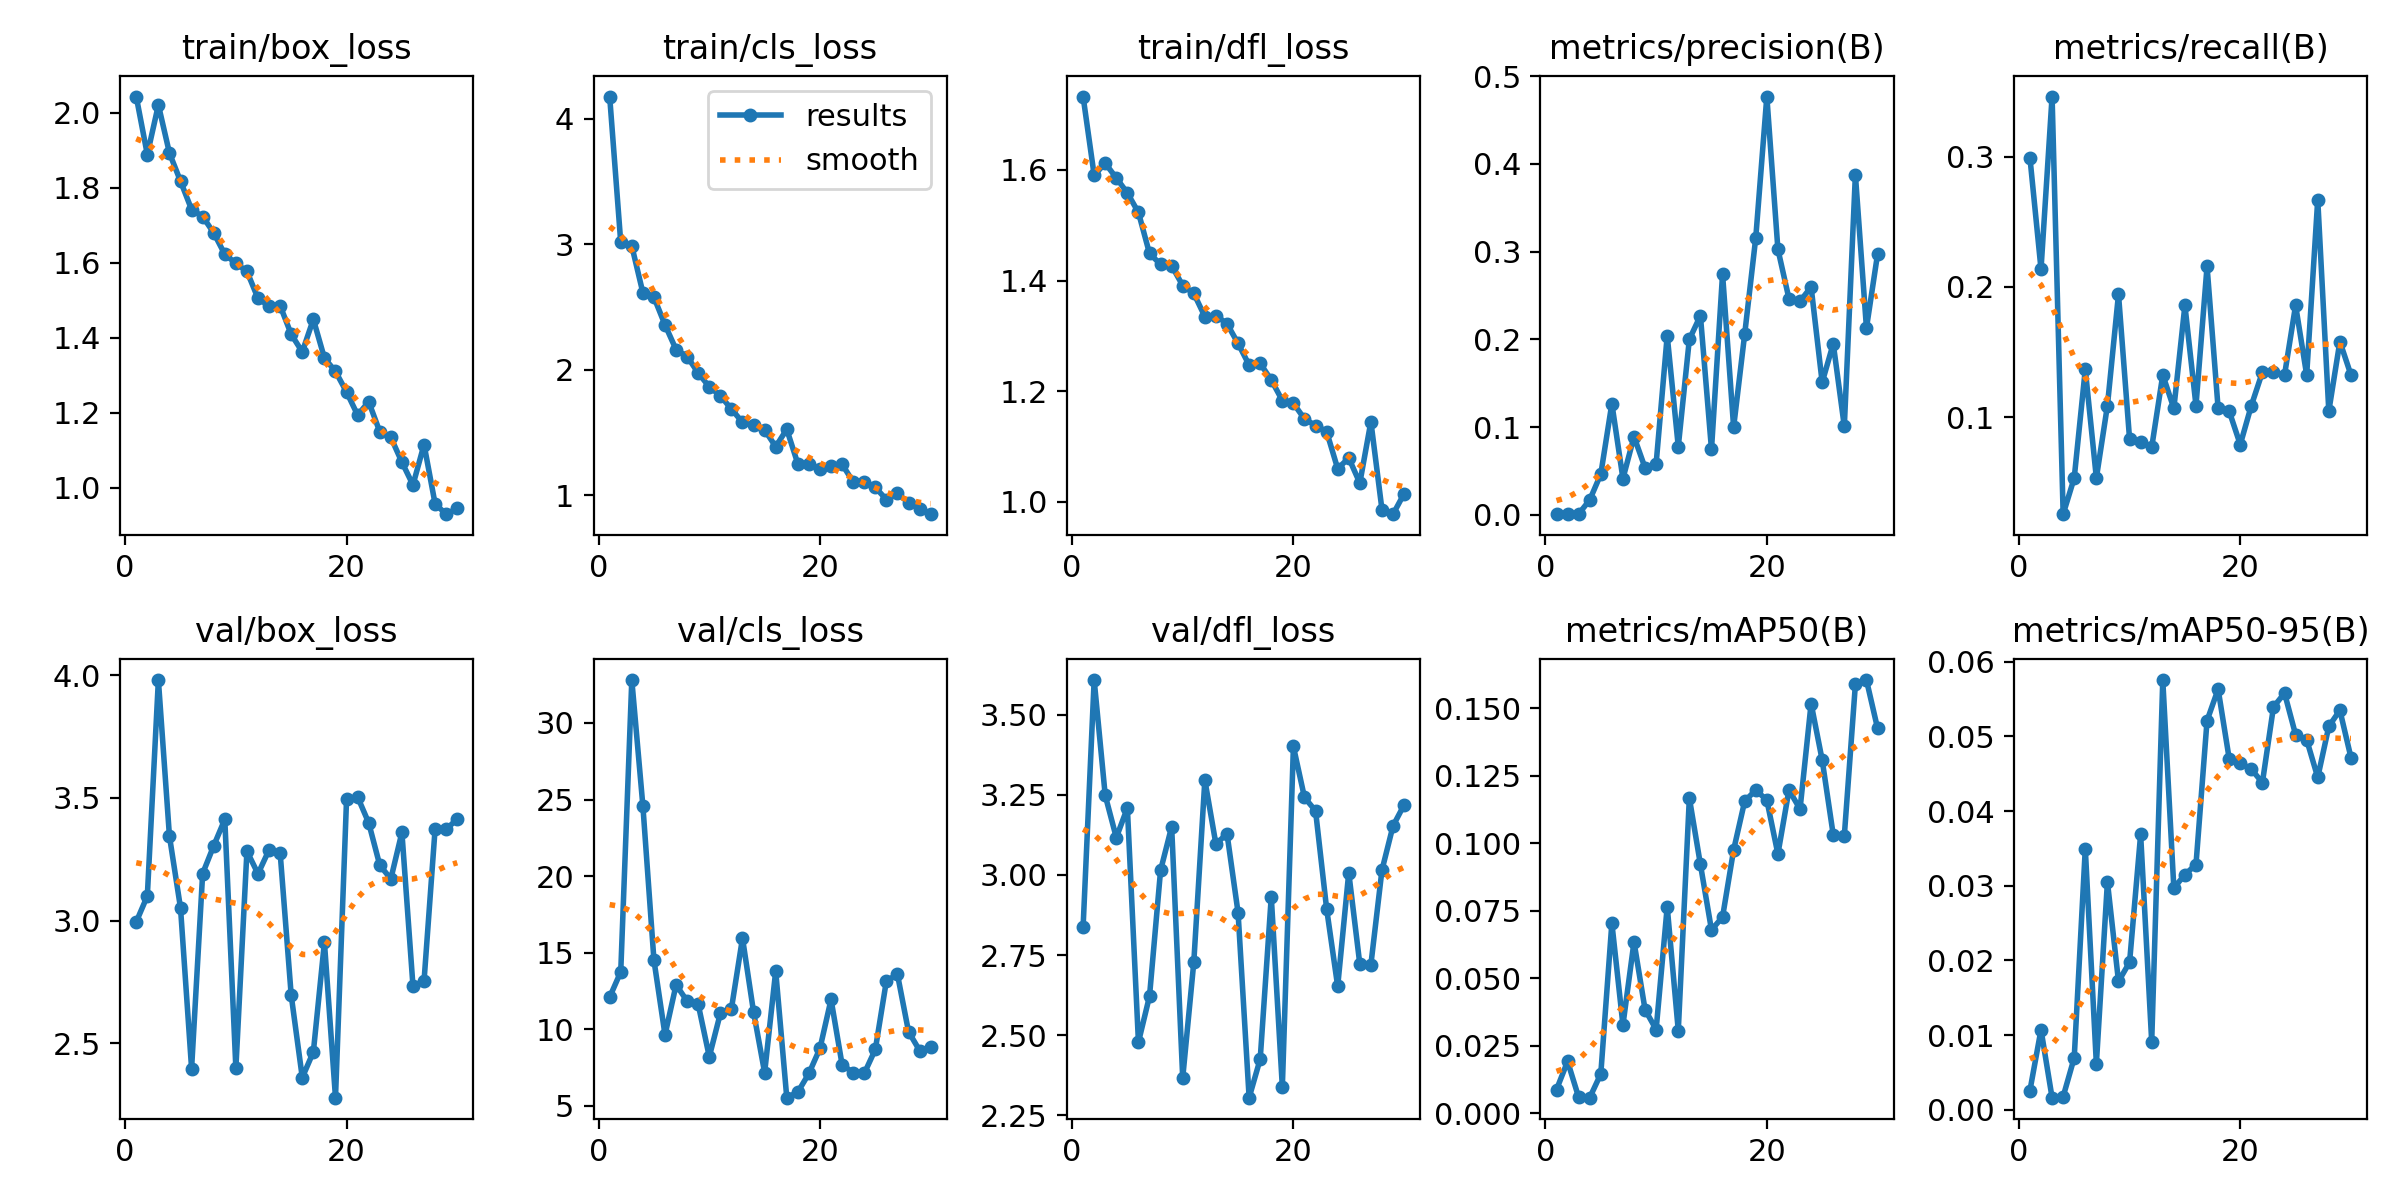

In [19]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/road_defect_results/yolov8n_baseline-2/results.png",
        width=1100
    )
)

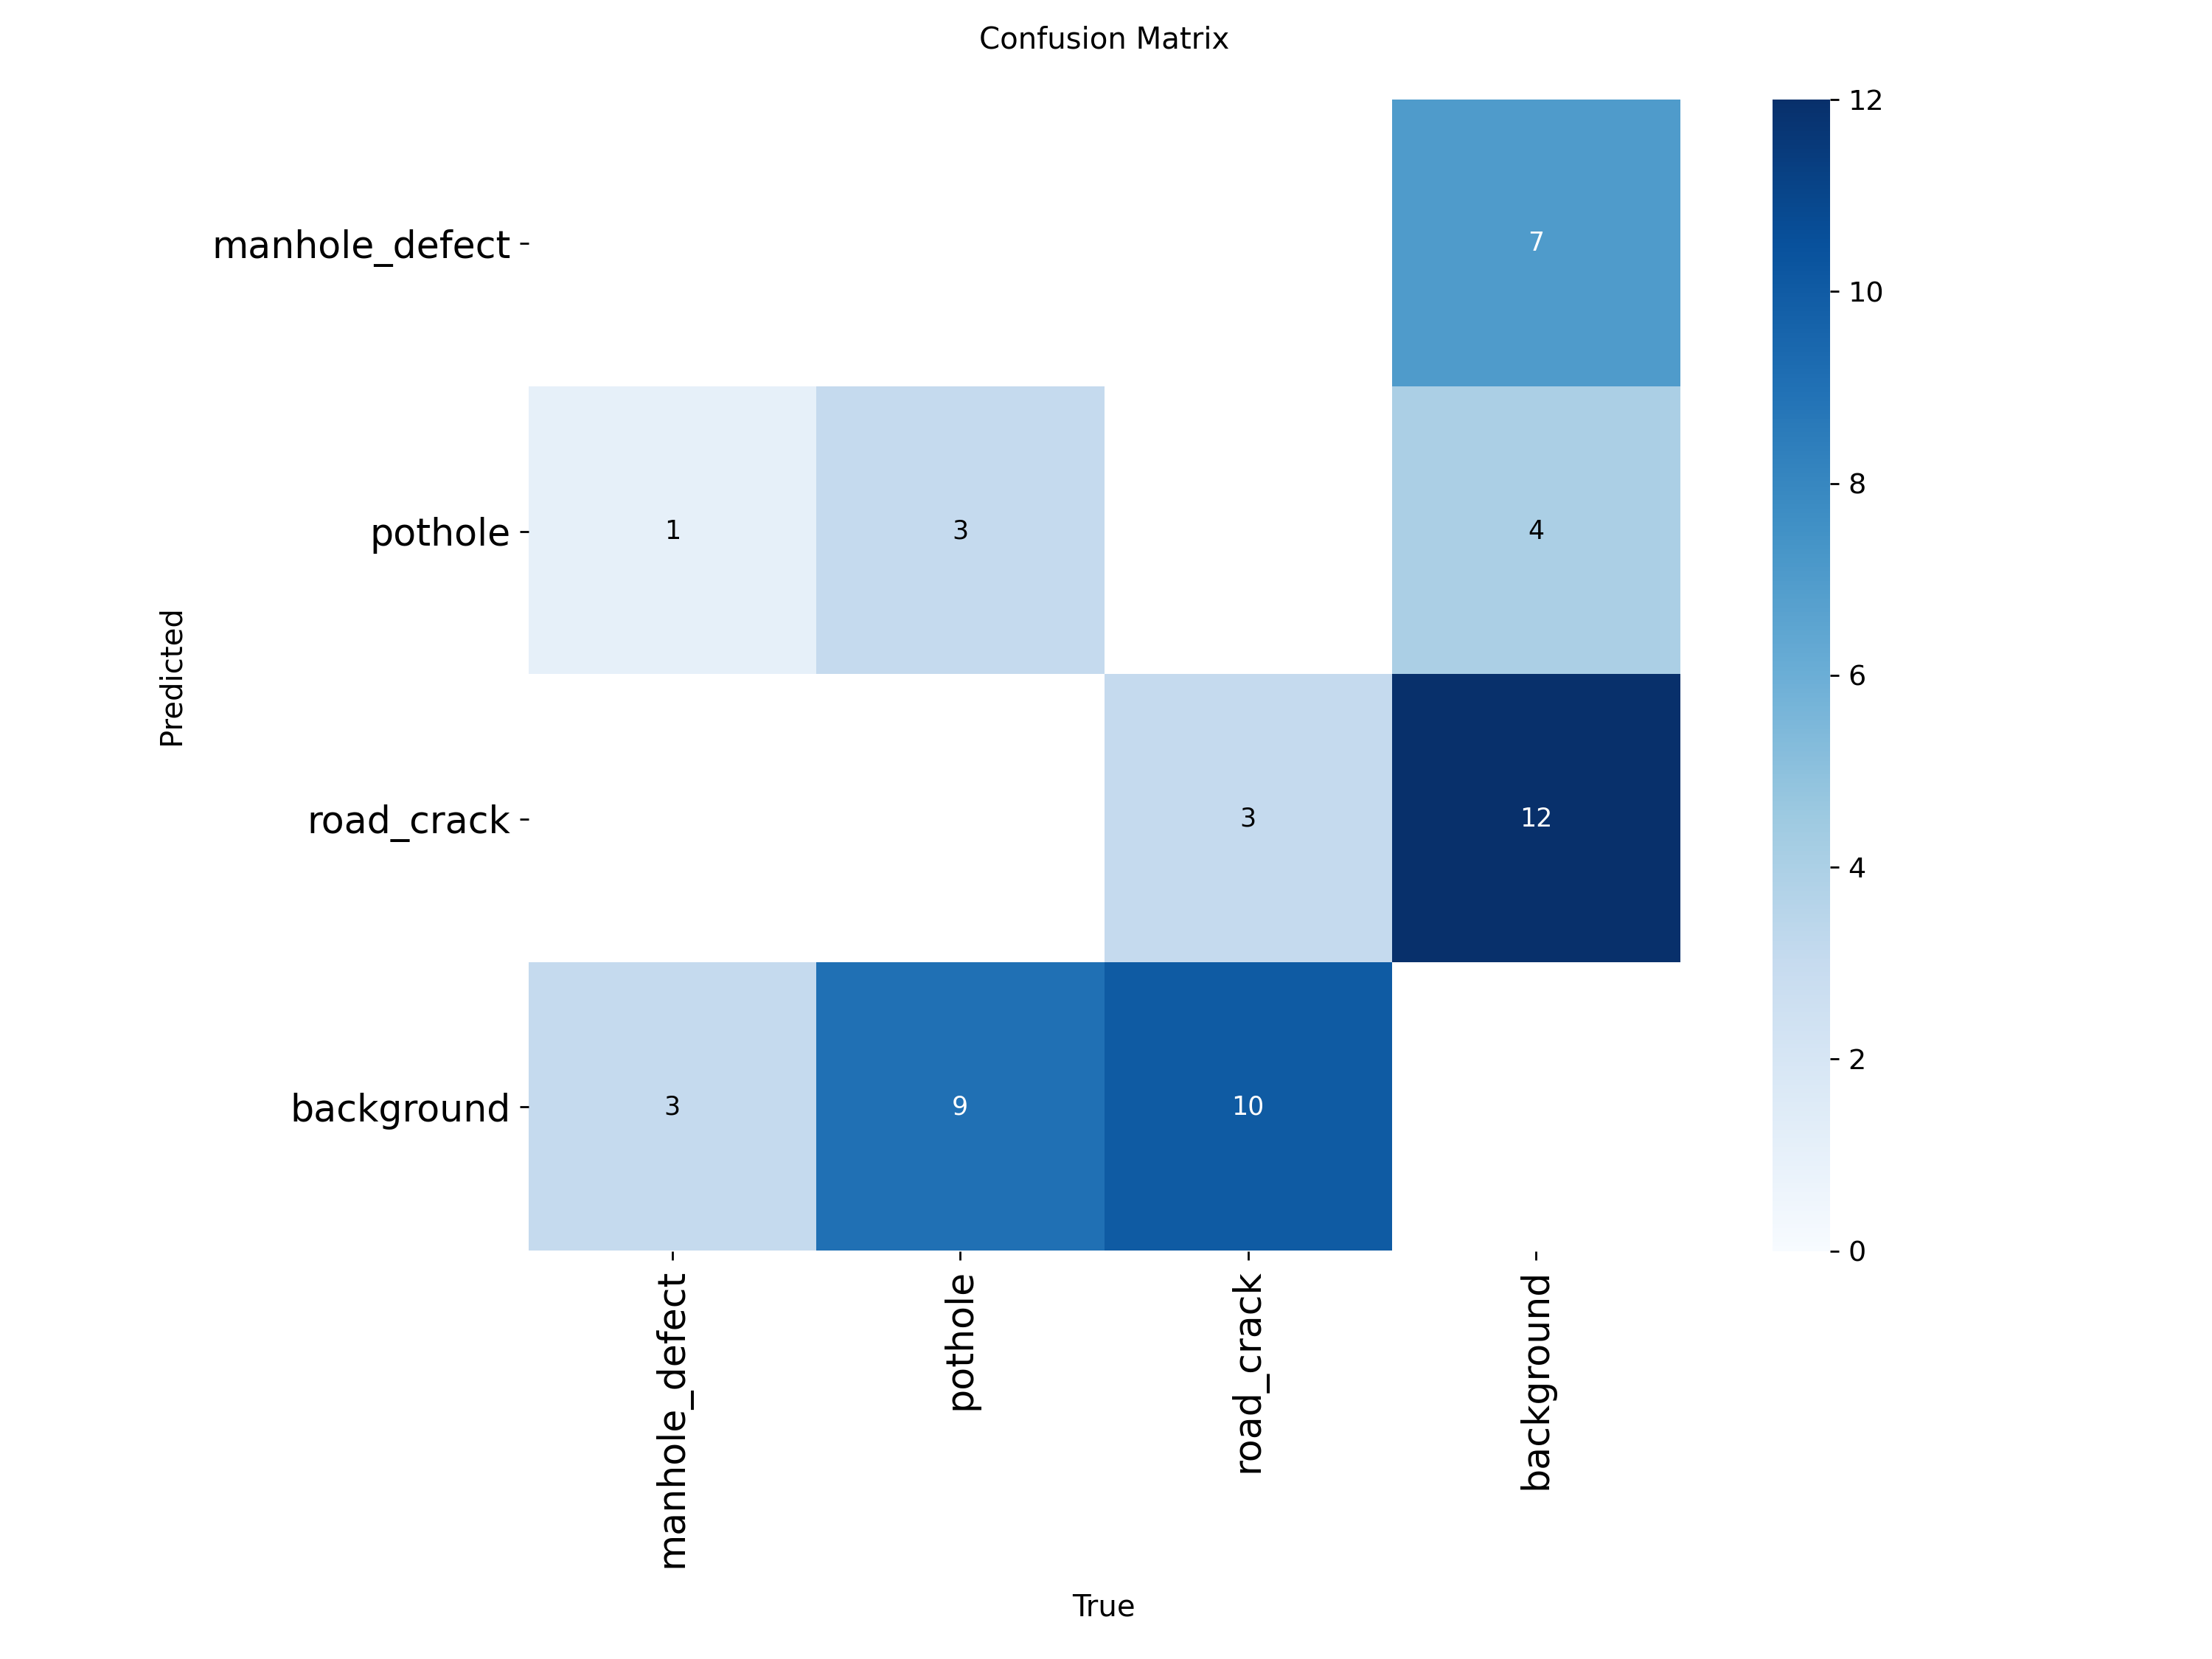

In [20]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/road_defect_results/yolov8n_baseline-2/confusion_matrix.png",
        width=800
    )
)

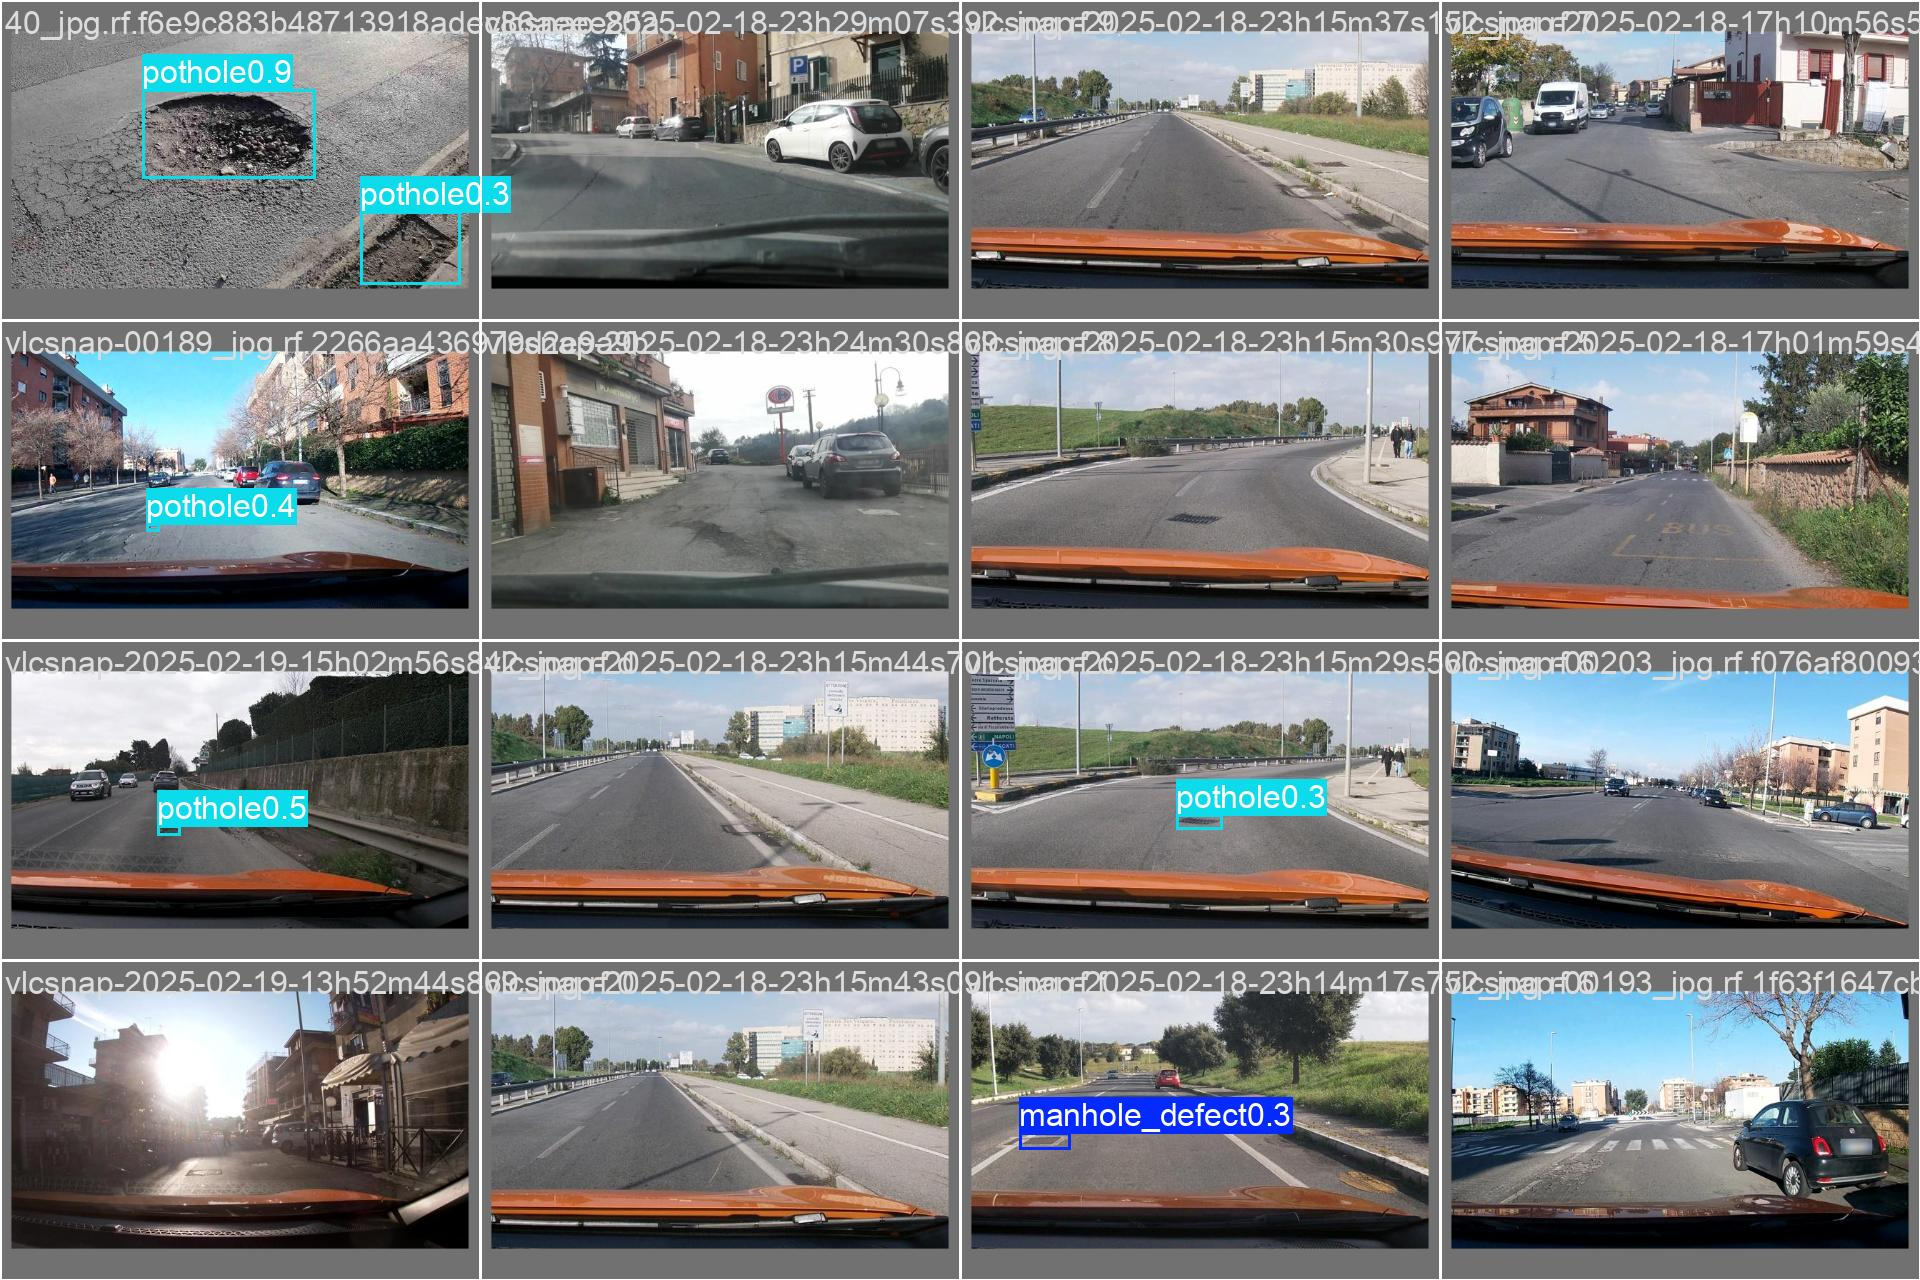

In [21]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/road_defect_results/yolov8n_baseline-2/val_batch0_pred.jpg",
        width=1100
    )
)

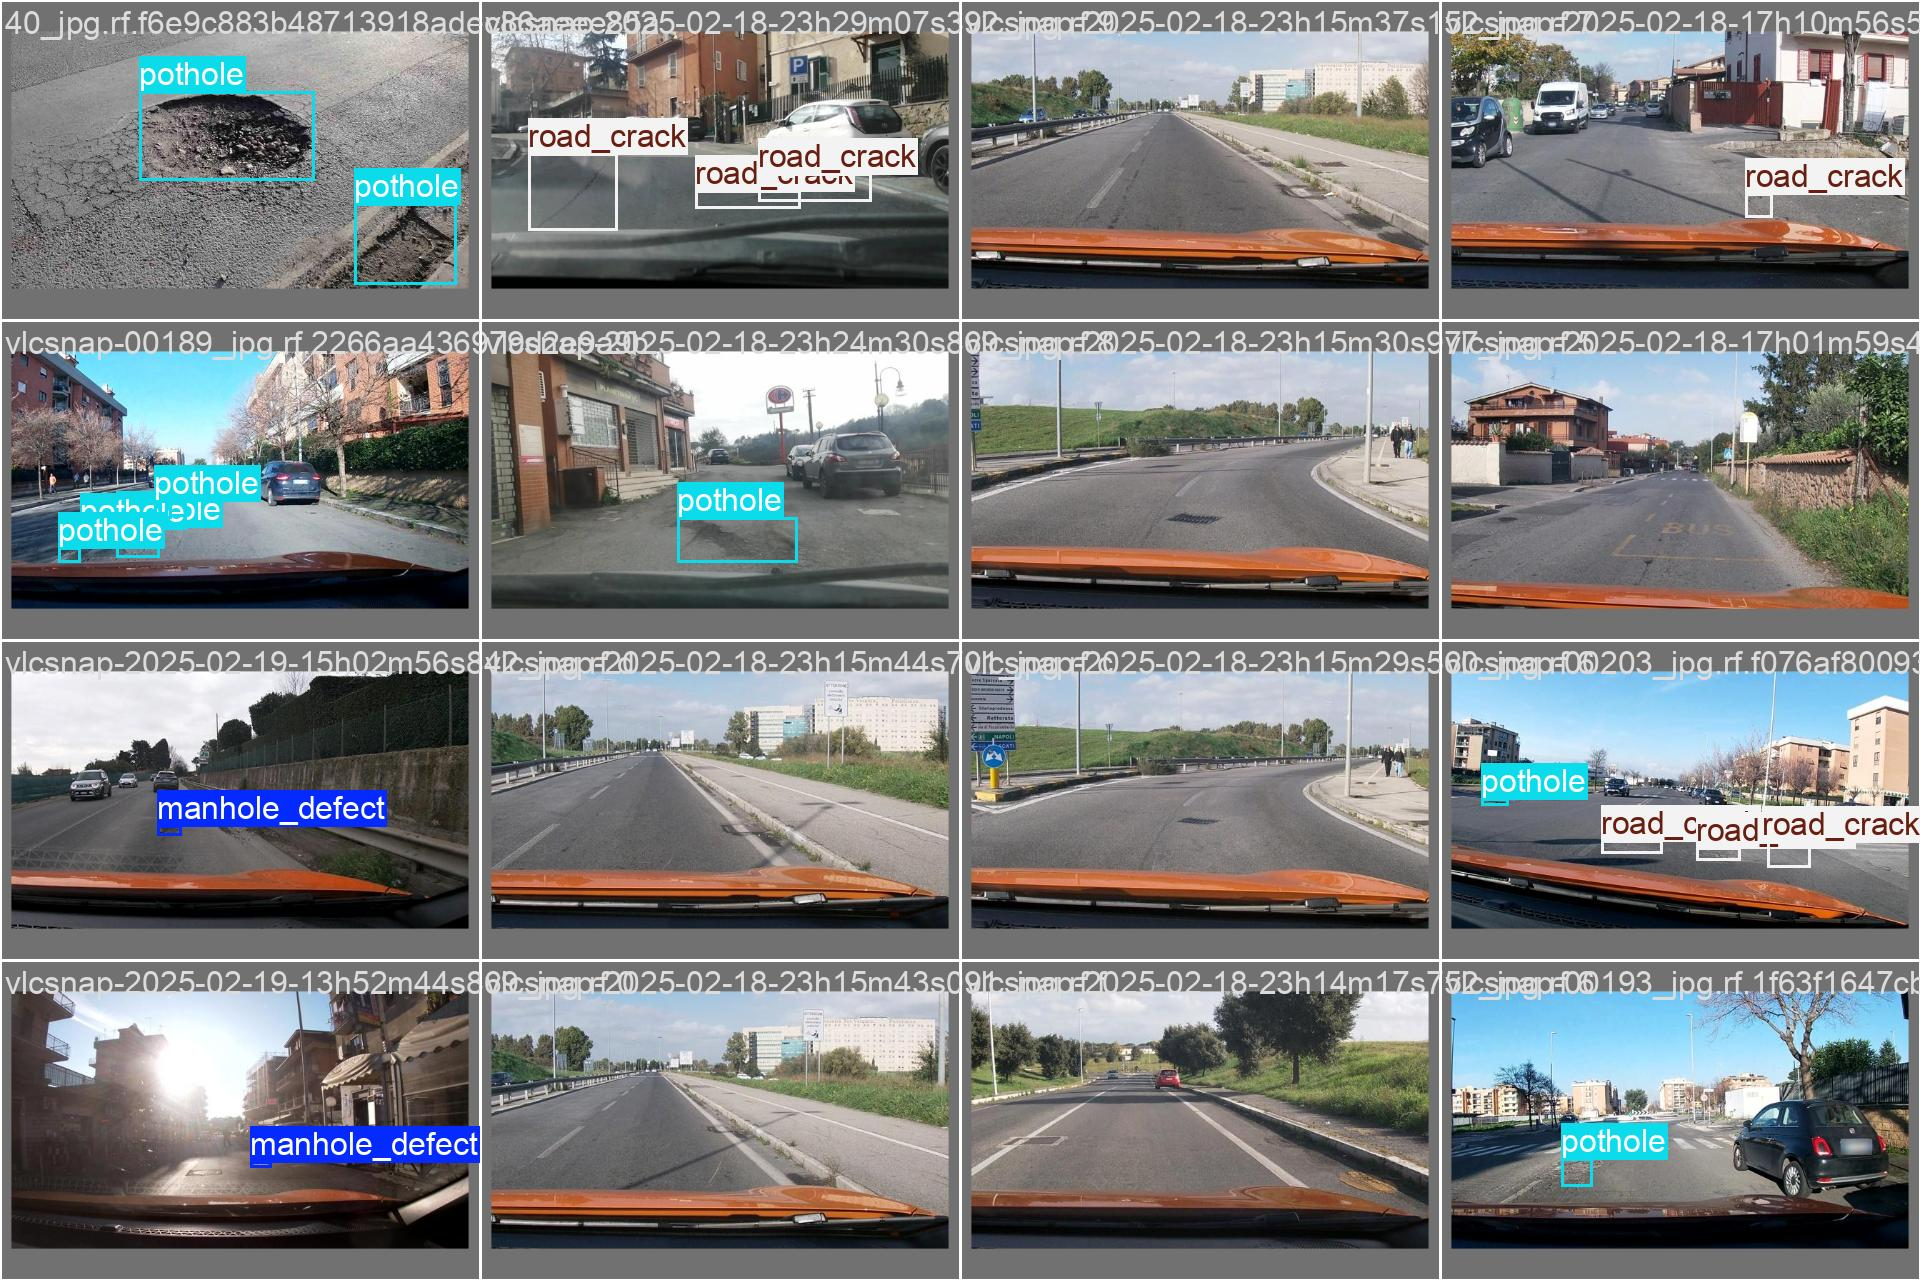

In [22]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/road_defect_results/yolov8n_baseline-2/val_batch0_labels.jpg",
        width=1100
    )
)

In [23]:
best_model = YOLO(
    "/content/road_defect_results/yolov8n_baseline-2/weights/best.pt"
)

metrics = best_model.val(
    data="/content/road_dataset/data.yaml"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2073.9±769.6 MB/s, size: 54.1 KB)
val: Scanning /content/road_dataset/valid/labels.cache... 37 images, 20 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 37/37 7.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.0it/s 1.5s
                   all         37         29      0.228      0.132      0.114     0.0564
        manhole_defect          4          4          0          0     0.0152    0.00838
               pothole          8         12      0.384      0.167      0.165      0.117
            road_crack          7         13      0.299      0.231      0.163     0.0442
Speed: 5.1ms preprocess, 14.3ms inference, 0.3ms loss, 4.5ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0

In [24]:
from google.colab import files
import os

os.makedirs("/content/new_test_images", exist_ok=True)

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, f"/content/new_test_images/{filename}")

print("New test images:", len(uploaded))

Saving 444.jpg to 444.jpg
Saving 333.jpg to 333.jpg
Saving vlcsnap-2025-02-19-17h05m08s806.jpg to vlcsnap-2025-02-19-17h05m08s806.jpg
Saving vlcsnap-2025-02-26-20h37m43s267.jpg to vlcsnap-2025-02-26-20h37m43s267.jpg
Saving 1004.jpg to 1004.jpg
New test images: 5


In [25]:
!ls -lh /content/new_test_images

total 664K
-rw-r--r-- 1 root root  49K Sep 16 07:47 1004.jpg
-rw-r--r-- 1 root root 105K Sep 16 07:47 333.jpg
-rw-r--r-- 1 root root 293K Sep 16 07:47 444.jpg
-rw-r--r-- 1 root root 110K Sep 16 07:47 vlcsnap-2025-02-19-17h05m08s806.jpg
-rw-r--r-- 1 root root  96K Sep 16 07:47 vlcsnap-2025-02-26-20h37m43s267.jpg


In [26]:
predictions = best_model.predict(
    source="/content/new_test_images",
    conf=0.25,
    imgsz=640,
    save=True,
    project="/content/road_defect_results",
    name="new_image_predictions"
)


image 1/5 /content/new_test_images/1004.jpg: 448x640 2 manhole_defects, 15.4ms
image 2/5 /content/new_test_images/333.jpg: 448x640 3 road_cracks, 15.0ms
image 3/5 /content/new_test_images/444.jpg: 480x640 3 road_cracks, 47.5ms
image 4/5 /content/new_test_images/vlcsnap-2025-02-19-17h05m08s806.jpg: 384x640 1 pothole, 41.7ms
image 5/5 /content/new_test_images/vlcsnap-2025-02-26-20h37m43s267.jpg: 384x640 2 road_cracks, 6.3ms
Speed: 2.0ms preprocess, 25.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/road_defect_results/new_image_predictions


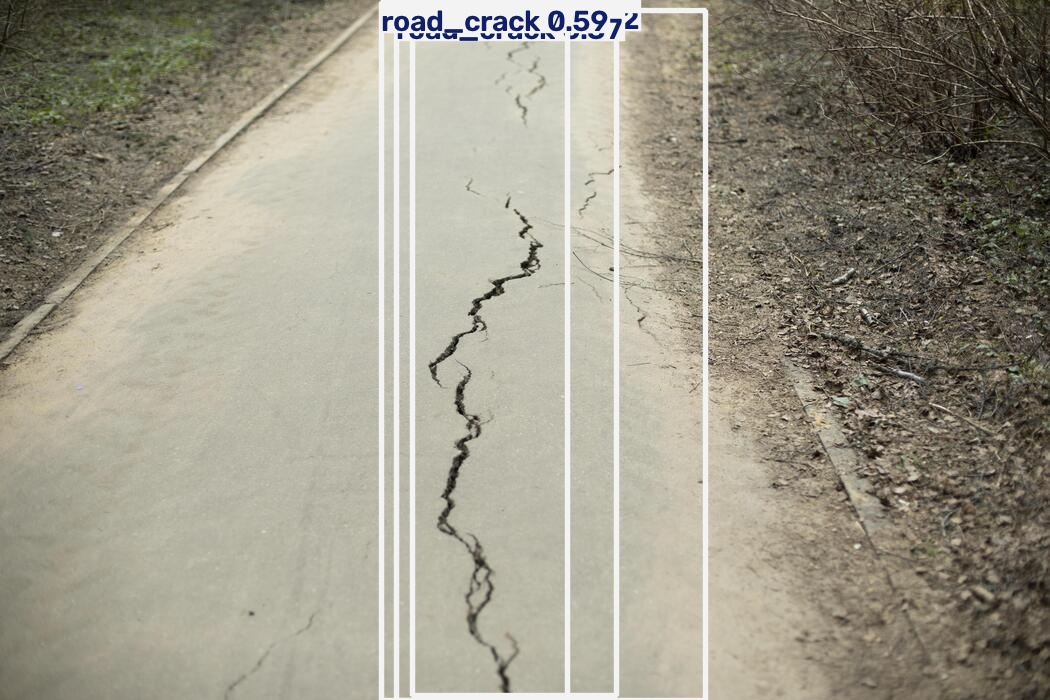

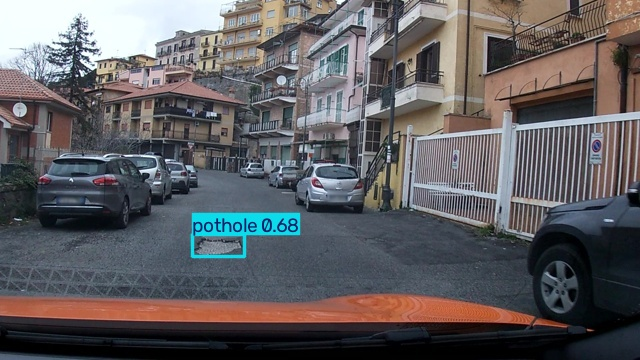

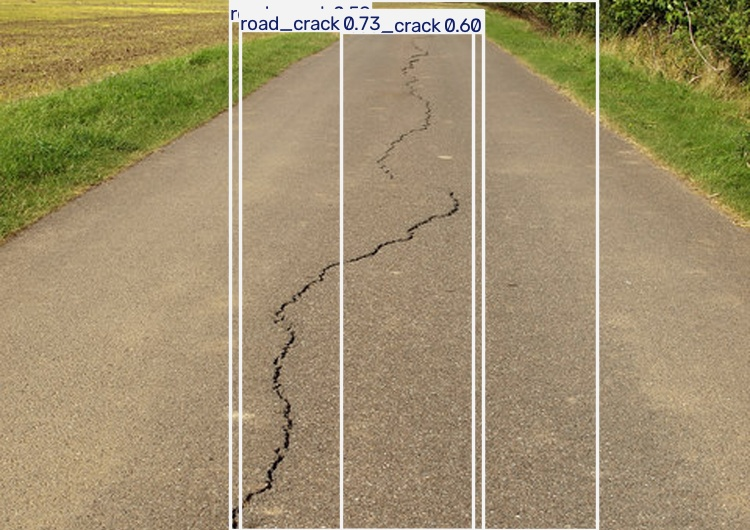

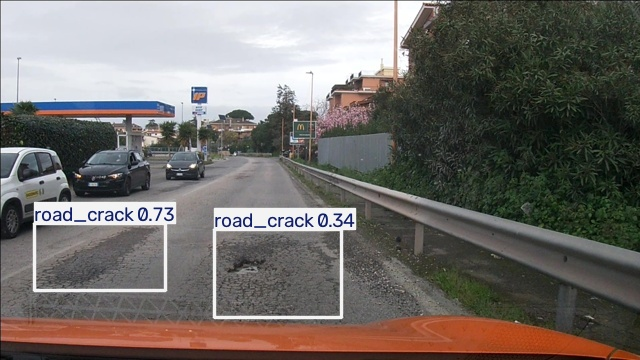

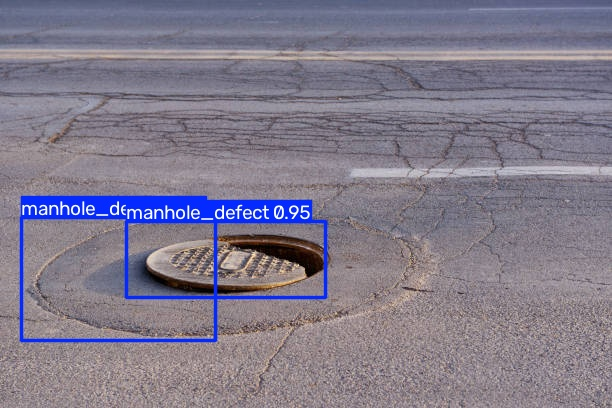

In [27]:
import glob
from IPython.display import Image, display

prediction_files = glob.glob(
    "/content/road_defect_results/new_image_predictions/*"
)

for file in prediction_files:
    display(Image(filename=file, width=700))

In [28]:
import os
import shutil

run_folder = "/content/road_defect_results/yolov8n_baseline-2"
package = "/content/road_defect_baseline_package"

os.makedirs(package, exist_ok=True)

print("Package folder created:", package)

Package folder created: /content/road_defect_baseline_package


In [29]:
files_to_save = [
    "weights/best.pt",
    "weights/last.pt",
    "results.png",
    "results.csv",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
    "val_batch0_pred.jpg",
    "val_batch0_labels.jpg"
]

for item in files_to_save:
    src = os.path.join(run_folder, item)

    if os.path.exists(src):
        filename = os.path.basename(item)
        shutil.copy2(src, os.path.join(package, filename))
        print("✓ Saved:", filename)
    else:
        print("Not found:", item)

✓ Saved: best.pt
✓ Saved: last.pt
✓ Saved: results.png
✓ Saved: results.csv
✓ Saved: confusion_matrix.png
✓ Saved: confusion_matrix_normalized.png
Not found: PR_curve.png
Not found: P_curve.png
Not found: R_curve.png
Not found: F1_curve.png
✓ Saved: val_batch0_pred.jpg
✓ Saved: val_batch0_labels.jpg


In [30]:
prediction_source = "/content/road_defect_results/new_image_predictions"
prediction_destination = os.path.join(package, "new_image_predictions")

if os.path.exists(prediction_source):
    shutil.copytree(
        prediction_source,
        prediction_destination,
        dirs_exist_ok=True
    )

    print("✓ Final new-image predictions copied.")

✓ Final new-image predictions copied.


In [31]:
!find /content/road_defect_baseline_package -maxdepth 2 -type f

/content/road_defect_baseline_package/val_batch0_labels.jpg
/content/road_defect_baseline_package/val_batch0_pred.jpg
/content/road_defect_baseline_package/results.png
/content/road_defect_baseline_package/results.csv
/content/road_defect_baseline_package/last.pt
/content/road_defect_baseline_package/confusion_matrix.png
/content/road_defect_baseline_package/best.pt
/content/road_defect_baseline_package/new_image_predictions/333.jpg
/content/road_defect_baseline_package/new_image_predictions/vlcsnap-2025-02-19-17h05m08s806.jpg
/content/road_defect_baseline_package/new_image_predictions/444.jpg
/content/road_defect_baseline_package/new_image_predictions/vlcsnap-2025-02-26-20h37m43s267.jpg
/content/road_defect_baseline_package/new_image_predictions/1004.jpg
/content/road_defect_baseline_package/confusion_matrix_normalized.png


In [32]:
import shutil

shutil.make_archive(
    "/content/road_defect_baseline_package",
    "zip",
    "/content/road_defect_baseline_package"
)

print("ZIP package created successfully.")

ZIP package created successfully.


In [33]:
!ls -lh /content/road_defect_baseline_package.zip

-rw-r--r-- 1 root root 13M Sep 16 07:51 /content/road_defect_baseline_package.zip


In [34]:
from google.colab import files

files.download("/content/road_defect_baseline_package.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>